In [1]:
import pandas as pd
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

/Users/johnny/Library/CloudStorage/OneDrive-Personal/py/JaneStreet2024/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pl.scan_parquet("training.parquet").collect().to_pandas()
valid = pl.scan_parquet("validation.parquet").collect().to_pandas()
train.shape, valid.shape

((8598744, 103), (13505536, 103))

In [3]:
train = pd.concat([train, valid]).reset_index(drop=True)
del valid
train.shape

(22104280, 103)

In [4]:
import optuna
from xgboost import XGBRegressor
import xgboost as xgb
from optuna_integration import XGBoostPruningCallback
from sklearn.metrics import r2_score
import numpy as np

def custom_metric(y_true,y_pred,weight):
    weighted_r2=1-(np.sum(weight*(y_true-y_pred)**2)/np.sum(weight*y_true**2))
    return weighted_r2

train_1 = train[:15000000]
train_1 = train_1.sample(frac=1, random_state=CONFIG.seed).reset_index(drop=True)
valid = train[15000000:]
del train
X_train = train_1[CONFIG.feature_cols]
y_train = train_1[CONFIG.target_col]
w_train = train_1["weight"]
X_valid = valid[CONFIG.feature_cols]
y_valid = valid[CONFIG.target_col]
w_valid = valid["weight"]
del valid


def objective(trial):
    XGB_Params = {
        "learning_rate": trial.suggest_float("learning_rate", 5e-4, 1e-1, log=True),
        "max_depth": trial.suggest_int("max_depth", 6, 12),
        # "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": CONFIG.seed,
        "eta": trial.suggest_float("eta", 0.1, 0.9),
        "tree_method": "hist",
        "max_bin": trial.suggest_int("max_bin", 128, 300),
        "objective": "reg:squarederror",
        "silent": 0,
    }

    num_boost_round = trial.suggest_int("num_boost_round", 80, 500)

    dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid, weight=w_valid)

    # pruning_callback = XGBoostPruningCallback(trial, "validation-rmse")
    evals = [(dvalid, "validation")]

    bst = xgb.train(
        XGB_Params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=4,
        # callbacks=[pruning_callback]
    )

    y_pred_valid = bst.predict(dvalid)
    valid_score = custom_metric(y_valid, y_pred_valid, w_valid)
    return valid_score


# Run optimization
# pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=80)
study = optuna.create_study(
    direction="maximize",
    # pruner=pruner,
)
study.optimize(objective, n_trials=200, gc_after_trial=True)

# Best parameters and score
print("Best trial:")
print("  Value: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2024-11-17 21:38:56,866] A new study created in memory with name: no-name-6f052e09-2667-4065-8e7b-2d2e64d507a1


[0]	validation-rmse:0.77774
[1]	validation-rmse:0.77768
[2]	validation-rmse:0.77762
[3]	validation-rmse:0.77757
[4]	validation-rmse:0.77751
[5]	validation-rmse:0.77745
[6]	validation-rmse:0.77740
[7]	validation-rmse:0.77735
[8]	validation-rmse:0.77730
[9]	validation-rmse:0.77725
[10]	validation-rmse:0.77720
[11]	validation-rmse:0.77715
[12]	validation-rmse:0.77711
[13]	validation-rmse:0.77707
[14]	validation-rmse:0.77702
[15]	validation-rmse:0.77698
[16]	validation-rmse:0.77694
[17]	validation-rmse:0.77690
[18]	validation-rmse:0.77686
[19]	validation-rmse:0.77682
[20]	validation-rmse:0.77679
[21]	validation-rmse:0.77675
[22]	validation-rmse:0.77671
[23]	validation-rmse:0.77668
[24]	validation-rmse:0.77665
[25]	validation-rmse:0.77661
[26]	validation-rmse:0.77658
[27]	validation-rmse:0.77655
[28]	validation-rmse:0.77652
[29]	validation-rmse:0.77649
[30]	validation-rmse:0.77646
[31]	validation-rmse:0.77643
[32]	validation-rmse:0.77639
[33]	validation-rmse:0.77636
[34]	validation-rmse:0.7

[I 2024-11-17 21:41:30,264] Trial 0 finished with value: 0.008369863033294678 and parameters: {'learning_rate': 0.01599643711743892, 'max_depth': 7, 'subsample': 0.6883762907922302, 'colsample_bytree': 0.9735780074663938, 'reg_alpha': 0.08604722906606109, 'reg_lambda': 0.00936540032904276, 'eta': 0.8177289383515384, 'max_bin': 128, 'num_boost_round': 226}. Best is trial 0 with value: 0.008369863033294678.


[0]	validation-rmse:0.77780
[1]	validation-rmse:0.77780
[2]	validation-rmse:0.77780
[3]	validation-rmse:0.77779
[4]	validation-rmse:0.77779
[5]	validation-rmse:0.77779
[6]	validation-rmse:0.77778
[7]	validation-rmse:0.77778
[8]	validation-rmse:0.77778
[9]	validation-rmse:0.77777
[10]	validation-rmse:0.77777
[11]	validation-rmse:0.77776
[12]	validation-rmse:0.77776
[13]	validation-rmse:0.77776
[14]	validation-rmse:0.77775
[15]	validation-rmse:0.77775
[16]	validation-rmse:0.77775
[17]	validation-rmse:0.77774
[18]	validation-rmse:0.77774
[19]	validation-rmse:0.77773
[20]	validation-rmse:0.77773
[21]	validation-rmse:0.77773
[22]	validation-rmse:0.77772
[23]	validation-rmse:0.77772
[24]	validation-rmse:0.77772
[25]	validation-rmse:0.77771
[26]	validation-rmse:0.77771
[27]	validation-rmse:0.77770
[28]	validation-rmse:0.77770
[29]	validation-rmse:0.77770
[30]	validation-rmse:0.77769
[31]	validation-rmse:0.77769
[32]	validation-rmse:0.77769
[33]	validation-rmse:0.77768
[34]	validation-rmse:0.7

[I 2024-11-17 21:46:07,495] Trial 1 finished with value: 0.0025742650032043457 and parameters: {'learning_rate': 0.000986339214566194, 'max_depth': 7, 'subsample': 0.8858103382905959, 'colsample_bytree': 0.7654948997796611, 'reg_alpha': 0.22245992355216046, 'reg_lambda': 0.00683807609352775, 'eta': 0.6875735292248412, 'max_bin': 294, 'num_boost_round': 343}. Best is trial 0 with value: 0.008369863033294678.


...

[0]	validation-rmse:0.77780
[1]	validation-rmse:0.77779
[2]	validation-rmse:0.77778
[3]	validation-rmse:0.77777
[4]	validation-rmse:0.77776
[5]	validation-rmse:0.77774
[6]	validation-rmse:0.77773
[7]	validation-rmse:0.77772
[8]	validation-rmse:0.77771
[9]	validation-rmse:0.77770
[10]	validation-rmse:0.77769
[11]	validation-rmse:0.77768
[12]	validation-rmse:0.77767
[13]	validation-rmse:0.77766
[14]	validation-rmse:0.77765
[15]	validation-rmse:0.77764
[16]	validation-rmse:0.77762
[17]	validation-rmse:0.77761
[18]	validation-rmse:0.77760
[19]	validation-rmse:0.77759
[20]	validation-rmse:0.77759
[21]	validation-rmse:0.77758
[22]	validation-rmse:0.77757
[23]	validation-rmse:0.77756
[24]	validation-rmse:0.77755
[25]	validation-rmse:0.77754
[26]	validation-rmse:0.77753
[27]	validation-rmse:0.77752
[28]	validation-rmse:0.77751
[29]	validation-rmse:0.77750
[30]	validation-rmse:0.77748
[31]	validation-rmse:0.77748
[32]	validation-rmse:0.77747
[33]	validation-rmse:0.77746
[34]	validation-rmse:0.7

[I 2024-11-18 17:10:40,250] Trial 198 finished with value: 0.007084250450134277 and parameters: {'learning_rate': 0.0023029301460594353, 'max_depth': 11, 'subsample': 0.6207716465071855, 'colsample_bytree': 0.5004269790744491, 'reg_alpha': 8.450907676721512, 'reg_lambda': 5.152908843669557, 'eta': 0.7218790439375391, 'max_bin': 128, 'num_boost_round': 486}. Best is trial 152 with value: 0.010364294052124023.


[0]	validation-rmse:0.77774
[1]	validation-rmse:0.77769
[2]	validation-rmse:0.77763
[3]	validation-rmse:0.77757
[4]	validation-rmse:0.77752
[5]	validation-rmse:0.77746
[6]	validation-rmse:0.77740
[7]	validation-rmse:0.77735
[8]	validation-rmse:0.77729
[9]	validation-rmse:0.77724
[10]	validation-rmse:0.77719
[11]	validation-rmse:0.77713
[12]	validation-rmse:0.77708
[13]	validation-rmse:0.77703
[14]	validation-rmse:0.77698
[15]	validation-rmse:0.77692
[16]	validation-rmse:0.77688
[17]	validation-rmse:0.77683
[18]	validation-rmse:0.77678
[19]	validation-rmse:0.77674
[20]	validation-rmse:0.77670
[21]	validation-rmse:0.77666
[22]	validation-rmse:0.77662
[23]	validation-rmse:0.77657
[24]	validation-rmse:0.77654
[25]	validation-rmse:0.77649
[26]	validation-rmse:0.77645
[27]	validation-rmse:0.77641
[28]	validation-rmse:0.77637
[29]	validation-rmse:0.77634
[30]	validation-rmse:0.77630
[31]	validation-rmse:0.77626
[32]	validation-rmse:0.77623
[33]	validation-rmse:0.77620
[34]	validation-rmse:0.7

[I 2024-11-18 17:15:23,006] Trial 199 finished with value: 0.009861588478088379 and parameters: {'learning_rate': 0.013466981900864506, 'max_depth': 11, 'subsample': 0.5840773893927587, 'colsample_bytree': 0.5216904501268549, 'reg_alpha': 3.946538290256903, 'reg_lambda': 9.255566638751972, 'eta': 0.6469279243625956, 'max_bin': 135, 'num_boost_round': 492}. Best is trial 152 with value: 0.010364294052124023.


Best trial:
  Value:  0.010364294052124023
  Params: 
    learning_rate: 0.011101917510070728
    max_depth: 11
    subsample: 0.6542079059226975
    colsample_bytree: 0.5183604553506279
    reg_alpha: 9.940677705743093
    reg_lambda: 4.986943153765948
    eta: 0.654320722467972
    max_bin: 137
    num_boost_round: 466


In [5]:
params = study.best_trial.params
params["tree_method"] = "hist"
params["objective"] = "reg:squarederror"
params["random_state"] = CONFIG.seed
params["n_estimators"] = params.pop("num_boost_round")

model = XGBRegressor(**params)
model.fit(X_train, y_train, sample_weight=w_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5183604553506279, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.654320722467972, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.011101917510070728,
             max_bin=137, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=11, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=466, n_jobs=None,
             num_parallel_tree=None, ...)

In [6]:
# y_pred_train1 = model.predict(X_train.iloc[:X_train.shape[0]//2])
# y_pred_train2 = model.predict(X_train.iloc[X_train.shape[0]//2:])
# train_score = r2_score(y_train, np.concatenate([y_pred_train1, y_pred_train2], axis=0), sample_weight=w_train )
# train_score

In [7]:
y_pred_valid = model.predict(X_valid)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
valid_score

0.010408639907836914

In [8]:
y_means = { symbol_id : -1 for symbol_id in range(39) }
for symbol_id, gdf in train[["symbol_id", CONFIG.target_col]].groupby("symbol_id"):
    y_mean = gdf[ CONFIG.target_col ].mean()
    y_means[symbol_id] = y_mean
    print(f"symbol_id = {symbol_id}, y_means = {y_mean:.5f}")

NameError: name 'train' is not defined

In [ ]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
# for symbol_id, gdf in train.groupby("symbol_id"):
#     X_valid = gdf[ CONFIG.feature_cols ][15000000:]
#     y_valid = gdf[ CONFIG.target_col ][15000000:]
#     w_valid = gdf[ "weight" ][15000000:]
#     y_pred_valid = model.predict(X_valid)
#     score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
#     cv_detail[symbol_id] = score
    
#     print(f"symbol_id = {symbol_id}, score = {score:.5f}")

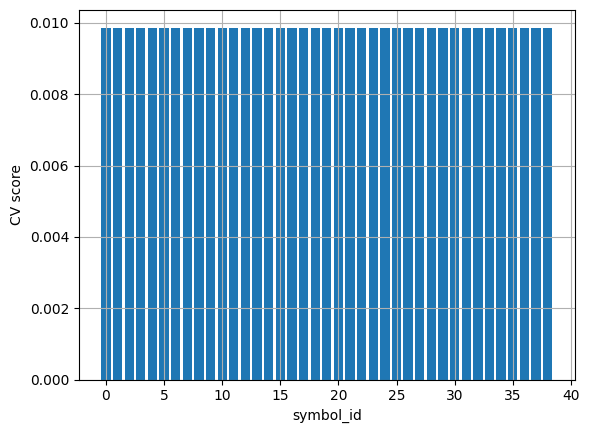

In [ ]:
# sids = list(cv_detail.keys())
# plt.bar(sids, [cv_detail[sid] for sid in sids])
# plt.grid()
# plt.xlabel("symbol_id")
# plt.ylabel("CV score")
# plt.show()

In [10]:
result = {
    "model" : model,
    "cv" : valid_score,
    # "cv_detail" : cv_detail,
    # "y_mean" : y_means,
}
with open("result_shuffled.pkl", "wb") as fp:
    pickle.dump(result, fp)